In [275]:
import pandas as pd
import networkx_temporal as tx
import numpy as np
import graph_tool.all as gt
import seaborn as sns

# STI spreading on network

- Behavior_1: Anal sex with/without condom?  (Yes: +1, No: -1, Information not available: 0)  
- Behavior_2: Oral sex with condom?          (Yes: +1, No: -1, Information not available: 0)  
- Behavior_3: Mouth kiss?                    (Yes: +1, No: -1, Information not available: 0)  

In [276]:
column_names = [
    "Female_id",
    "Male_id",
    "Date_days",
    "Grade",
    "Behavoir_1",
    "Behavior_2",
    "Behavior_3"
]

df_sex_contacts = pd.read_csv(
    'Datasets/pcbi.1001109.s001.csv',
    comment='#',
    sep=';',
    names=column_names
)

In [277]:
df_sex_contacts

,Female_id,Male_id,Date_days,Grade,Behavoir_1,Behavior_2,Behavior_3
0,0,1,0,0,0,0,0
1,2,1,0,1,-1,1,-1
2,3,1,0,0,0,0,0
3,0,4,21,0,0,0,0
4,5,6,47,0,0,0,0
...,...,...,...,...,...,...,...
50627,16724,13831,2231,0,-1,1,1
50628,16725,14958,2231,1,0,1,1
50629,16368,10049,2232,1,-1,1,1
50630,16726,16727,2232,1,1,1,1


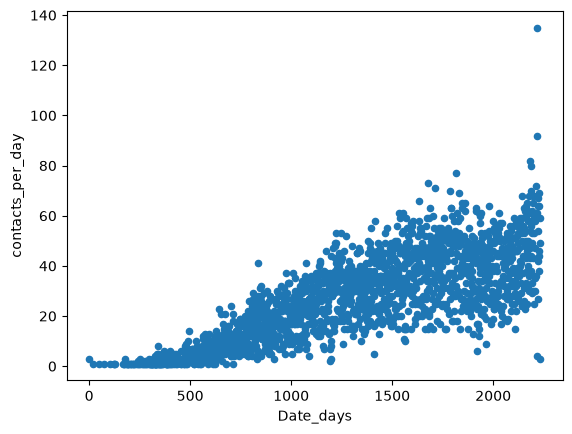

In [278]:
df_daily_contacts = df_sex_contacts.groupby('Date_days').size().reset_index(name='contacts_per_day')
df_daily_contacts.plot(x='Date_days', y='contacts_per_day', kind='scatter');

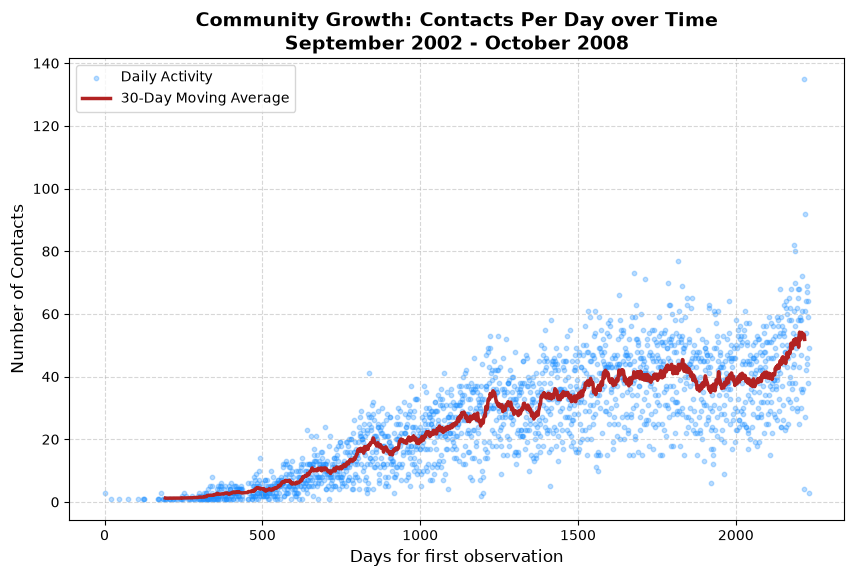

In [279]:
import matplotlib.pyplot as plt

# 1. Calculate a 30-day rolling average to smooth the data
df_daily_contacts['rolling_30'] = df_daily_contacts['contacts_per_day'].rolling(window=30, center=True).mean()

plt.figure(figsize=(10, 6))

# Plot the original data faintly in the background
plt.scatter(df_daily_contacts['Date_days'], df_daily_contacts['contacts_per_day'], 
            alpha=0.3, color='dodgerblue', s=10, label='Daily Activity')

# Overlay the clean trend line
plt.plot(df_daily_contacts['Date_days'], df_daily_contacts['rolling_30'], 
         color='firebrick', linewidth=2.5, label='30-Day Moving Average')

plt.title('Community Growth: Contacts Per Day over Time\nSeptember 2002 - October 2008', fontsize=14, fontweight='bold')
plt.xlabel('Days for first observation', fontsize=12)
plt.ylabel('Number of Contacts', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Check power law distribution

In [280]:
# add months count

bins = np.arange(0, 2260, 30)
labels = np.arange(1, len(bins))
df_sex_contacts["Month_count"] = pd.cut(
    df_sex_contacts["Date_days"], bins=bins, labels=labels, right=False
)
df_sex_contacts["Month_count"] = df_sex_contacts["Month_count"].astype(int)
df_sex_contacts

,Female_id,Male_id,Date_days,Grade,Behavoir_1,Behavior_2,Behavior_3,Month_count
0,0,1,0,0,0,0,0,1
1,2,1,0,1,-1,1,-1,1
2,3,1,0,0,0,0,0,1
3,0,4,21,0,0,0,0,1
4,5,6,47,0,0,0,0,2
...,...,...,...,...,...,...,...,...
50627,16724,13831,2231,0,-1,1,1,75
50628,16725,14958,2231,1,0,1,1,75
50629,16368,10049,2232,1,-1,1,1,75
50630,16726,16727,2232,1,1,1,1,75


In [281]:
df_sex_contacts[df_sex_contacts['Month_count'] == 75]

,Female_id,Male_id,Date_days,Grade,Behavoir_1,Behavior_2,Behavior_3,Month_count
50006,11194,16470,2220,1,1,1,1,75
50007,12115,16545,2220,1,1,1,1,75
50008,12115,1879,2220,1,1,1,1,75
50009,11538,12080,2220,1,-1,1,1,75
50010,11545,1468,2220,1,1,1,1,75
...,...,...,...,...,...,...,...,...
50627,16724,13831,2231,0,-1,1,1,75
50628,16725,14958,2231,1,0,1,1,75
50629,16368,10049,2232,1,-1,1,1,75
50630,16726,16727,2232,1,1,1,1,75


Define a temporal network.

In [282]:
# Build weighted edgelist: one entry per unique (Female_id, Male_id, Month_count)
# Weight = number of contacts between that pair within the same month
df_weighted = (
    df_sex_contacts
    .groupby(['Female_id', 'Male_id', 'Month_count'])
    .size()
    .reset_index(name='weight')
)

G = gt.Graph(directed=False)

unique_ids = np.unique(np.concatenate([df_sex_contacts['Female_id'], df_sex_contacts['Male_id']]))
id_to_vertex = {original_id: G.add_vertex() for original_id in unique_ids}

v_id_map = G.new_vertex_property("int")
for original_id, vertex in id_to_vertex.items():
    v_id_map[vertex] = original_id
G.vertex_properties["original_id"] = v_id_map

ep_month  = G.new_edge_property("int")
ep_weight = G.new_edge_property("int")

for _, row in df_weighted.iterrows():
    u = id_to_vertex[row['Female_id']]
    v = id_to_vertex[row['Male_id']]
    e = G.add_edge(u, v)
    ep_month[e]  = row['Month_count']
    ep_weight[e] = row['weight']

G.edge_properties["month"]  = ep_month
G.edge_properties["weight"] = ep_weight

print(f"Weighted graph: {G.num_vertices()} nodes, {G.num_edges()} unique temporal edges")
print(f"Original contact rows: {len(df_sex_contacts)}, unique (pair, month) edges: {len(df_weighted)}")
print(df_weighted[df_weighted['weight'] > 1].head(5))

Weighted graph: 16730 nodes, 48134 unique temporal edges
Original contact rows: 50632, unique (pair, month) edges: 48134
     Female_id  Male_id  Month_count  weight
122          9     2301           57       3
125          9     2301           62       2
154          9     5701           51       2
251         11     6496           43       2
256         11     6704           55       2


In [283]:
import powerlaw
from collections import Counter

snapshots = sorted(df_sex_contacts['Month_count'].unique())
results = []

for month in snapshots:
    df_snap = df_sex_contacts[df_sex_contacts['Month_count'] == month]

    # Degree of each node = number of contacts in this snapshot
    degree_counter = Counter()
    degree_counter.update(df_snap['Female_id'])
    degree_counter.update(df_snap['Male_id'])
    degrees = list(degree_counter.values())

    if len(degrees) < 10:
        continue

    fit = powerlaw.Fit(degrees, discrete=True, verbose=False)
    results.append({
        'month':   month,
        'n_nodes': len(degrees),
        'n_edges': len(df_snap),
        'alpha':   fit.power_law.alpha,
        'xmin':    fit.power_law.xmin,
    })

df_results = pd.DataFrame(results)
df_results.head(10)

/opt/anaconda3/envs/sfi_sti_model/lib/python3.14/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
/opt/anaconda3/envs/sfi_sti_model/lib/python3.14/site-packages/powerlaw.py:699: RuntimeWarning: divide by zero encountered in divide
  (CDF_diff**2) /


,month,n_nodes,n_edges,alpha,xmin
0,6,10,6,2.202246,1.0
1,7,15,8,2.352527,1.0
2,9,17,12,2.021909,1.0
3,10,22,13,2.220742,1.0
4,11,48,34,3.364977,2.0
5,12,74,55,3.203958,2.0
6,13,84,63,4.834645,3.0
7,14,112,89,3.127218,3.0
8,15,70,48,2.790633,2.0
9,16,91,72,2.698979,2.0


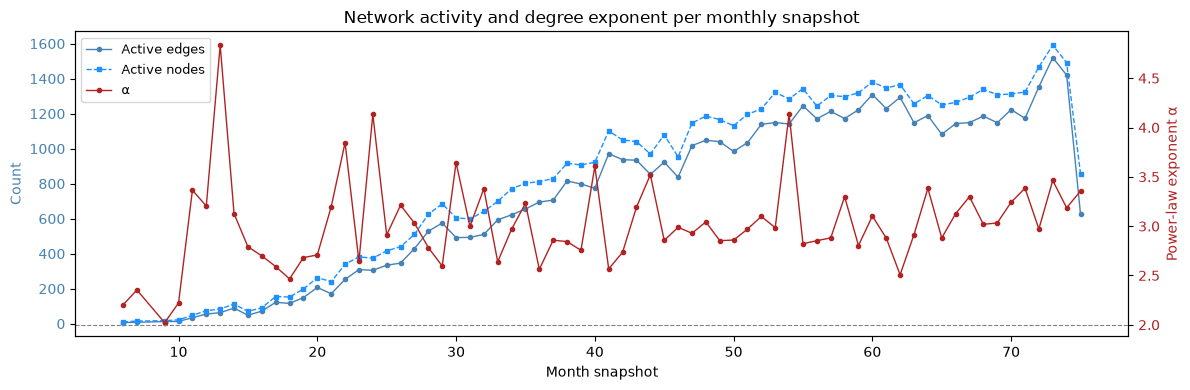

 month  n_nodes  n_edges    alpha  xmin
     6       10        6 2.202246   1.0
     7       15        8 2.352527   1.0
     9       17       12 2.021909   1.0
    10       22       13 2.220742   1.0
    11       48       34 3.364977   2.0
    12       74       55 3.203958   2.0
    13       84       63 4.834645   3.0
    14      112       89 3.127218   3.0
    15       70       48 2.790633   2.0
    16       91       72 2.698979   2.0
    17      155      122 2.590491   2.0
    18      152      116 2.465408   2.0
    19      198      149 2.681253   3.0
    20      263      207 2.707970   2.0
    21      240      171 3.195501   3.0
    22      339      253 3.845889   4.0
    23      382      309 2.644062   2.0
    24      374      305 4.133165   9.0
    25      416      334 2.911374   3.0
    26      440      346 3.212478   3.0
    27      510      429 3.030804   3.0
    28      625      528 2.782842   2.0
    29      685      575 2.596219   2.0
    30      605      492 3.643698   5.0


In [284]:
fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.plot(df_results['month'], df_results['n_edges'], color='steelblue', marker='o',
         markersize=3, linewidth=1, label='Active edges')
ax1.plot(df_results['month'], df_results['n_nodes'], color='dodgerblue', marker='s',
         markersize=3, linewidth=1, linestyle='--', label='Active nodes')
ax1.set_xlabel('Month snapshot')
ax1.set_ylabel('Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(df_results['month'], df_results['alpha'], color='firebrick', marker='o',
         markersize=3, linewidth=1, label='α')
ax2.axhline(2.0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Power-law exponent α', color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.title('Network activity and degree exponent per monthly snapshot')
plt.tight_layout()
plt.show()

print(df_results[['month', 'n_nodes', 'n_edges', 'alpha', 'xmin']].to_string(index=False))

<>:23: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:35: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:23: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:35: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/q_/n08xblxj1bq8yczcg1l1p1t40000gn/T/ipykernel_21288/2454125254.py:23: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  ax1.set_ylabel('$P(K \geq k)$', fontsize=12)
/var/folders/q_/n08xblxj1bq8yczcg1l1p1t40000gn/T/ipykernel_21288/2454125254.py:35: SyntaxWarning: "\g" is a

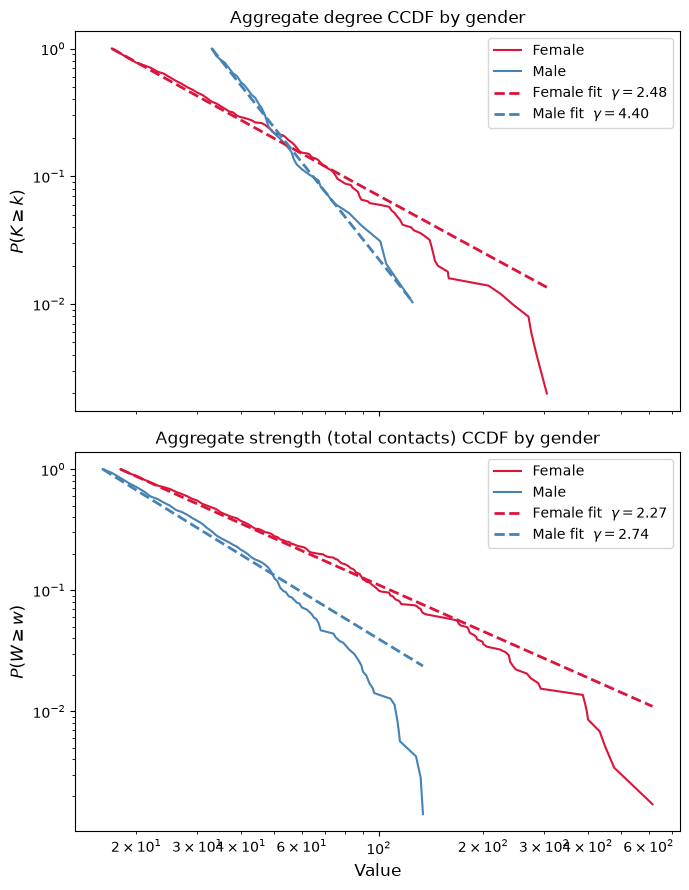

In [285]:
# Aggregate degree = number of unique partners per node across all time
agg_deg_f = df_sex_contacts.groupby('Female_id')['Male_id'].nunique().values
agg_deg_m = df_sex_contacts.groupby('Male_id')['Female_id'].nunique().values

# Aggregate strength = total number of contacts per node across all time
agg_str_f = df_sex_contacts.groupby('Female_id').size().values
agg_str_m = df_sex_contacts.groupby('Male_id').size().values

fit_df = powerlaw.Fit(agg_deg_f, discrete=True, verbose=False)
fit_dm = powerlaw.Fit(agg_deg_m, discrete=True, verbose=False)
fit_wf = powerlaw.Fit(agg_str_f, discrete=True, verbose=False)
fit_wm = powerlaw.Fit(agg_str_m, discrete=True, verbose=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 9), sharex=True)

# Top: degree CCDF by gender with power-law fit
fit_df.plot_ccdf(ax=ax1, color='crimson',   linewidth=1.5, label='Female')
fit_dm.plot_ccdf(ax=ax1, color='steelblue', linewidth=1.5, label='Male')
fit_df.power_law.plot_ccdf(ax=ax1, color='crimson',   linewidth=2, linestyle='--',
                            label=fr'Female fit  $\gamma={fit_df.power_law.alpha:.2f}$')
fit_dm.power_law.plot_ccdf(ax=ax1, color='steelblue', linewidth=2, linestyle='--',
                            label=fr'Male fit  $\gamma={fit_dm.power_law.alpha:.2f}$')
ax1.set_ylabel('$P(K \geq k)$', fontsize=12)
ax1.set_title('Aggregate degree CCDF by gender', fontsize=12)
ax1.legend(fontsize=10)

# Bottom: strength (weighted degree) CCDF by gender with power-law fit
fit_wf.plot_ccdf(ax=ax2, color='crimson',   linewidth=1.5, label='Female')
fit_wm.plot_ccdf(ax=ax2, color='steelblue', linewidth=1.5, label='Male')
fit_wf.power_law.plot_ccdf(ax=ax2, color='crimson',   linewidth=2, linestyle='--',
                            label=fr'Female fit  $\gamma={fit_wf.power_law.alpha:.2f}$')
fit_wm.power_law.plot_ccdf(ax=ax2, color='steelblue', linewidth=2, linestyle='--',
                            label=fr'Male fit  $\gamma={fit_wm.power_law.alpha:.2f}$')
ax2.set_xlabel('Value', fontsize=12)
ax2.set_ylabel('$P(W \geq w)$', fontsize=12)
ax2.set_title('Aggregate strength (total contacts) CCDF by gender', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

/opt/anaconda3/envs/sfi_sti_model/lib/python3.14/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
/opt/anaconda3/envs/sfi_sti_model/lib/python3.14/site-packages/powerlaw.py:699: RuntimeWarning: divide by zero encountered in divide
  (CDF_diff**2) /


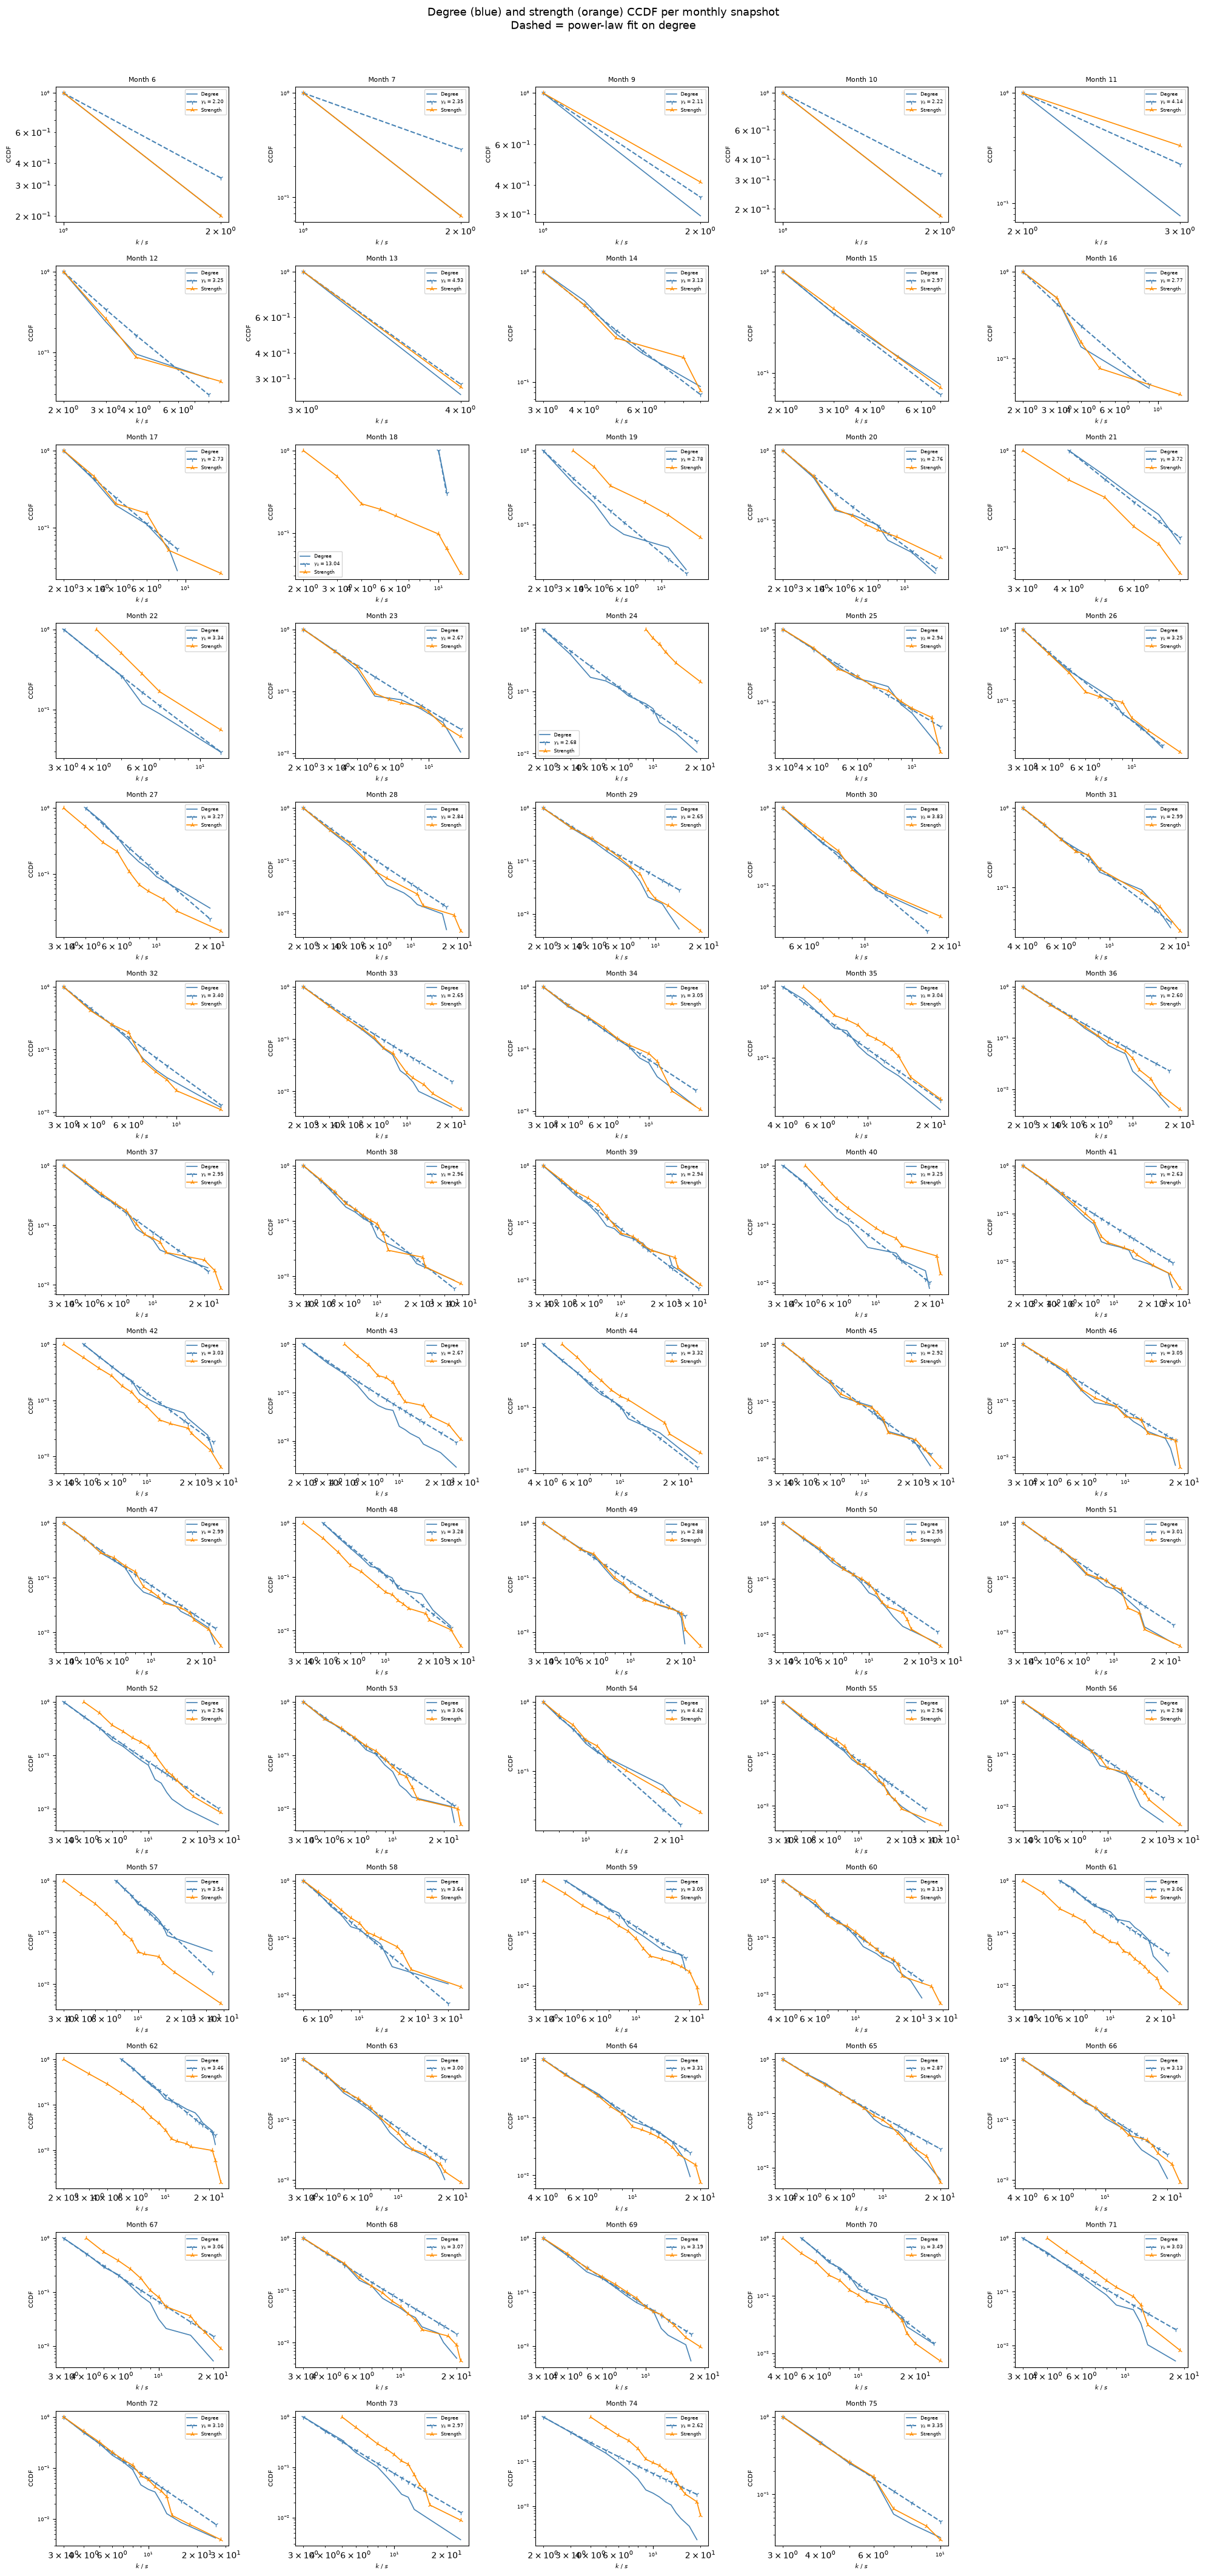

In [286]:
# Pre-aggregate weights per (node, month) for strength computation
node_strength_snap = (
    df_weighted
    .melt(id_vars=['Month_count', 'weight'],
          value_vars=['Female_id', 'Male_id'],
          value_name='node')
    .groupby(['node', 'Month_count'])['weight']
    .sum()
    .reset_index()
)

valid_months = [int(row['month']) for _, row in df_results.iterrows()]

n_cols = 5
n_rows = int(np.ceil(len(valid_months) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax, month in zip(axes, valid_months):
    df_snap = df_sex_contacts[df_sex_contacts['Month_count'] == month]

    # Degree = unique partners per node in this snapshot
    deg_f = df_snap.groupby('Female_id')['Male_id'].nunique()
    deg_m = df_snap.groupby('Male_id')['Female_id'].nunique()
    degrees = np.concatenate([deg_f.values, deg_m.values])

    # Strength = sum of edge weights per node in this snapshot
    strengths = node_strength_snap[node_strength_snap['Month_count'] == month]['weight'].values

    # Degree CCDF + power-law fit
    fit = powerlaw.Fit(degrees, discrete=True, verbose=False)
    fit.plot_ccdf(ax=ax, color='steelblue', linewidth=1.2, label='Degree')
    fit.power_law.plot_ccdf(ax=ax, color='steelblue', linewidth=1.5, linestyle='--',
                             label=fr'$\gamma_k={fit.power_law.alpha:.2f}$', marker='1')

    # Strength CCDF — empirical only, no fit
    fit_s = powerlaw.Fit(strengths, discrete=True, verbose=False)
    fit_s.plot_ccdf(ax=ax, color='darkorange', linewidth=1.2, label='Strength', marker='2')

    ax.set_title(f'Month {month}', fontsize=8)
    ax.set_xlabel('$k$ / $s$', fontsize=7)
    ax.set_ylabel('CCDF', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=6)

for ax in axes[len(valid_months):]:
    ax.set_visible(False)

plt.suptitle('Degree (blue) and strength (orange) CCDF per monthly snapshot\n'
             'Dashed = power-law fit on degree', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


# Epidemic modelling

Doubts:
- Assignation of initial spreaders should be based on data.
- How many simulations

In [287]:
def assign_transmission_rates(df_contacts, criterion='random',
                               beta_low=0.1, beta_high=0.75,
                               high_degree_fraction=0.20):
    """
    Assign a transmission rate to every node in the dataset.

    Parameters
    ----------
    df_contacts : DataFrame
        Full contact dataframe with Female_id, Male_id columns.
    criterion : str
        'random'     — high/low assigned at random
        'high_to_hub' — high beta assigned to high-degree nodes (top fraction)
        'high_to_low' — high beta assigned to low-degree nodes (bottom fraction)
    beta_low : float
        Transmission rate for low-beta nodes.
    beta_high : float
        Transmission rate for high-beta nodes.
    high_degree_fraction : float
        Fraction of nodes considered high-degree (default 0.20 → top 20%).

    Returns
    -------
    dict : node_id -> beta
    """
    # Aggregate degree across all snapshots
    agg_degree = Counter()
    agg_degree.update(df_contacts['Female_id'])
    agg_degree.update(df_contacts['Male_id'])

    all_nodes = np.array(list(agg_degree.keys()))
    degrees   = np.array([agg_degree[n] for n in all_nodes])

    # Threshold: top high_degree_fraction are "hubs"
    threshold = np.quantile(degrees, 1.0 - high_degree_fraction)
    is_hub    = degrees >= threshold

    if criterion == 'random':
        high_mask = np.random.rand(len(all_nodes)) < high_degree_fraction

    elif criterion == 'high_to_hub':
        high_mask = is_hub

    elif criterion == 'high_to_low':
        high_mask = ~is_hub

    else:
        raise ValueError(f"criterion must be 'random', 'high_to_hub', or 'high_to_low'. Got '{criterion}'.")

    beta_map = {
        node: (beta_high if h else beta_low)
        for node, h in zip(all_nodes, high_mask)
    }
    return beta_map

In [288]:
def run_SI_simulations(df_contacts, beta_map,
                       n_simulations=100, n_seeds=3):
    """
    Run multiple SI epidemic simulations on the weighted temporal network.

    Transmission probability for an edge (u→v) in snapshot t:
        p = min(1, weight(u,v,t) * beta(u))

    Parameters
    ----------
    df_contacts : DataFrame
        Full contact dataframe with Female_id, Male_id, Month_count.
    beta_map : dict
        node_id -> base transmission rate (from assign_transmission_rates).
    n_simulations : int
        Number of independent simulations to run.
    n_seeds : int
        Number of randomly chosen infected nodes at snapshot 1.

    Returns
    -------
    infected_counts : np.ndarray, shape (n_simulations, n_snapshots)
    snapshots : list
    """
    snapshots = sorted(df_contacts['Month_count'].unique())
    all_nodes = list(set(df_contacts['Female_id']) | set(df_contacts['Male_id']))

    # Pre-build weighted edge list per snapshot: month -> list of (u, v, weight)
    df_w = (
        df_contacts
        .groupby(['Female_id', 'Male_id', 'Month_count'])
        .size()
        .reset_index(name='weight')
    )
    edges_by_month = {
        month: list(zip(grp['Female_id'], grp['Male_id'], grp['weight']))
        for month, grp in df_w.groupby('Month_count')
    }

    infected_counts = np.zeros((n_simulations, len(snapshots)), dtype=int)

    for sim in range(n_simulations):
        infected = set(np.random.choice(all_nodes, size=n_seeds, replace=False))

        for t, month in enumerate(snapshots):
            new_infected = set()
            for u, v, w in edges_by_month.get(month, []):
                if u in infected and v not in infected:
                    if np.random.rand() < min(1.0, w * beta_map.get(u, 0.1)):
                        new_infected.add(v)
                if v in infected and u not in infected:
                    if np.random.rand() < min(1.0, w * beta_map.get(v, 0.1)):
                        new_infected.add(u)

            infected |= new_infected
            infected_counts[sim, t] = len(infected)

    return infected_counts, snapshots

In [289]:
def run_SIS_simulations(df_contacts, beta_map,
                        n_simulations=100, n_seeds=3,
                        recovery_time_years=1.0):
    """
    Run multiple SIS epidemic simulations on the weighted temporal network.

    Transmission (S→I): same as SI — probability = min(1, weight * beta(u)).
    Recovery   (I→S):   deterministic — a node recovers at the first snapshot
                        that is >= recovery_time_years * 12 months after it
                        was infected. Recovered nodes are fully susceptible again.

    Parameters
    ----------
    df_contacts : DataFrame
        Full contact dataframe with Female_id, Male_id, Month_count.
    beta_map : dict
        node_id -> base transmission rate (from assign_transmission_rates).
    n_simulations : int
        Number of independent simulations to run.
    n_seeds : int
        Number of randomly chosen infected nodes at the start of snapshot 1.
    recovery_time_years : float
        Time in years after which an infected node recovers. Each snapshot
        corresponds to one month, so recovery happens after
        round(recovery_time_years * 12) snapshots (default 1 year = 12 snapshots).

    Returns
    -------
    infected_counts : np.ndarray, shape (n_simulations, n_snapshots)
        Number of infected individuals at each snapshot for every simulation.
    snapshots : list
        Ordered list of month values corresponding to columns.
    """
    snapshots = sorted(df_contacts['Month_count'].unique())
    snap_index = {month: t for t, month in enumerate(snapshots)}
    all_nodes  = list(set(df_contacts['Female_id']) | set(df_contacts['Male_id']))

    recovery_snapshots = round(recovery_time_years * 12)

    df_w = (
        df_contacts
        .groupby(['Female_id', 'Male_id', 'Month_count'])
        .size()
        .reset_index(name='weight')
    )
    edges_by_month = {
        month: list(zip(grp['Female_id'], grp['Male_id'], grp['weight']))
        for month, grp in df_w.groupby('Month_count')
    }

    infected_counts = np.zeros((n_simulations, len(snapshots)), dtype=int)

    for sim in range(n_simulations):
        # infection_time[node] = snapshot index at which the node was infected
        infection_time = {
            node: 0
            for node in np.random.choice(all_nodes, size=n_seeds, replace=False)
        }

        for t, month in enumerate(snapshots):
            # --- Recovery: nodes whose infection has lasted >= recovery_snapshots ---
            recovered = {
                node for node, t_inf in infection_time.items()
                if (t - t_inf) >= recovery_snapshots
            }
            for node in recovered:
                del infection_time[node]

            infected = set(infection_time.keys())

            # --- Transmission ---
            new_infected = {}
            for u, v, w in edges_by_month.get(month, []):
                if u in infected and v not in infected and v not in new_infected:
                    if np.random.rand() < min(1.0, w * beta_map.get(u, 0.1)):
                        new_infected[v] = t
                if v in infected and u not in infected and u not in new_infected:
                    if np.random.rand() < min(1.0, w * beta_map.get(v, 0.1)):
                        new_infected[u] = t

            infection_time.update(new_infected)
            infected_counts[sim, t] = len(infection_time)

    return infected_counts, snapshots

## SI simulation

In [290]:
# Run 100 simulations for each assignment criterion
criteria = ['random', 'high_to_hub', 'high_to_low']
sim_results = {}

for criterion in criteria:
    beta_map = assign_transmission_rates(df_sex_contacts, criterion=criterion)
    counts, snapshots = run_SI_simulations(df_sex_contacts, beta_map, n_simulations=1000)
    sim_results[criterion] = counts

print("Simulations complete.")

Simulations complete.


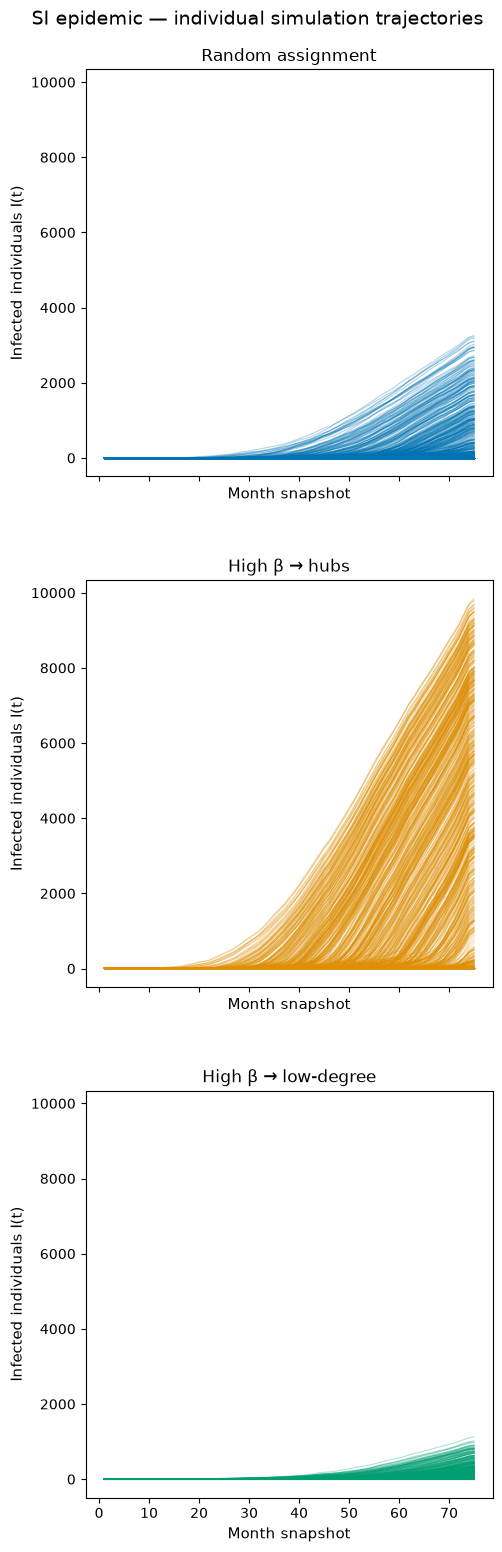

In [291]:
criteria = ['random', 'high_to_hub', 'high_to_low']
titles   = ['Random assignment', 'High β → hubs', 'High β → low-degree']
palette  = sns.color_palette('colorblind', n_colors=len(criteria))

fig, axes = plt.subplots(3, 1, figsize=(5, 16), sharex=True, sharey=True)

for ax, criterion, title, color in zip(axes, criteria, titles, palette):
    for run in sim_results[criterion]:
        ax.plot(snapshots, run, color=color, linewidth=0.8, alpha=0.3)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Month snapshot', fontsize=11)
    ax.set_ylabel('Infected individuals I(t)', fontsize=11)
    ax.set_box_aspect(1)

plt.suptitle('SI epidemic — individual simulation trajectories', fontsize=14)
plt.tight_layout()
plt.show()

### Infected aggregated by risk category

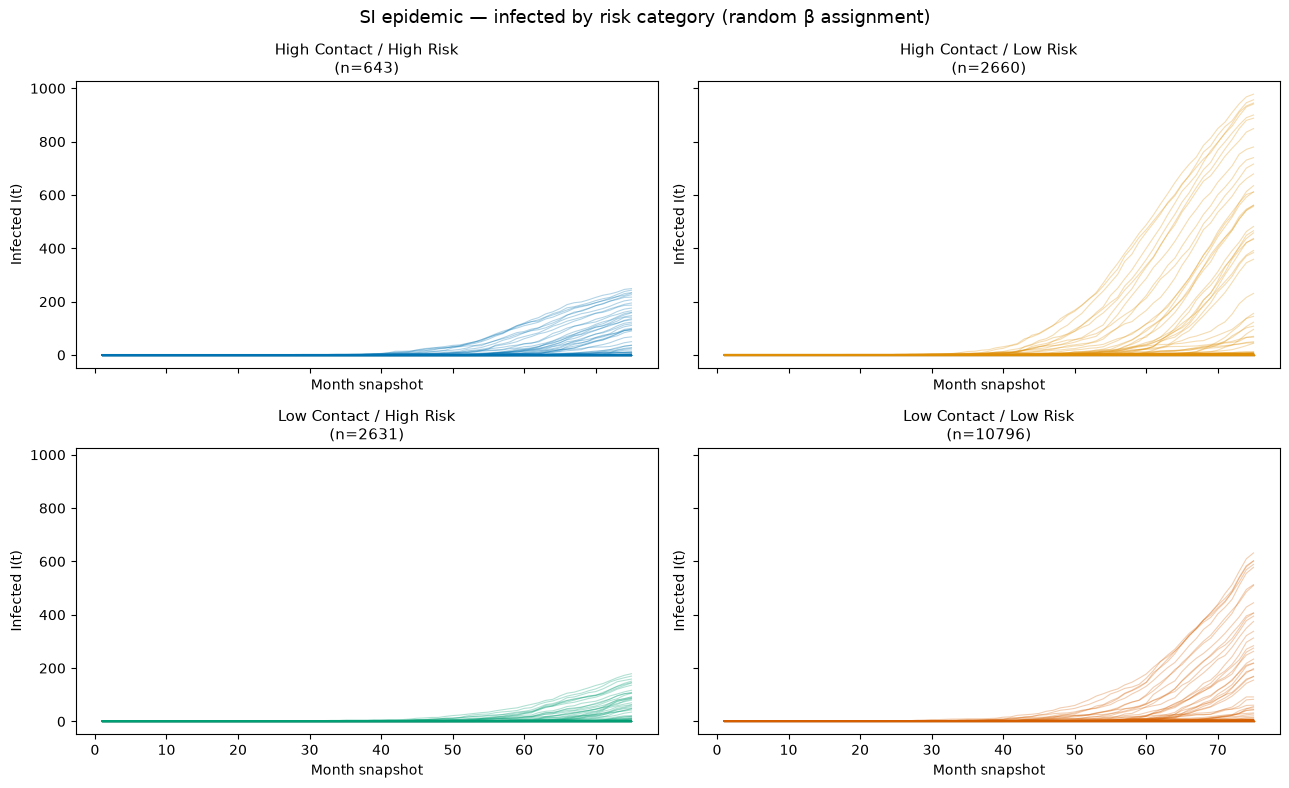

In [292]:
# --- Build risk categories ---
# Contact activity: above/below mean aggregate degree
agg_degree = Counter()
agg_degree.update(df_sex_contacts['Female_id'])
agg_degree.update(df_sex_contacts['Male_id'])
mean_degree = np.mean(list(agg_degree.values()))

# Use the random beta_map from the SI sim_results run
beta_map_cat = assign_transmission_rates(df_sex_contacts, criterion='random')
beta_values  = sorted(set(beta_map_cat.values()))
beta_low_val, beta_high_val = beta_values[0], beta_values[-1]

def get_category(node):
    activity  = 'high contact' if agg_degree[node] >= mean_degree else 'low contact'
    behaviour = 'high risk'    if beta_map_cat[node] == beta_high_val else 'low risk'
    return (activity, behaviour)

cat_labels = [
    ('high contact', 'high risk'),
    ('high contact', 'low risk'),
    ('low contact',  'high risk'),
    ('low contact',  'low risk'),
]
node_category = {node: get_category(node) for node in agg_degree}
cat_sizes     = {cat: sum(1 for c in node_category.values() if c == cat) for cat in cat_labels}

# --- SI simulation tracking per category ---
all_nodes = list(agg_degree.keys())
n_seeds   = 3
n_sims    = 100
snapshots_list = sorted(df_sex_contacts['Month_count'].unique())

df_w = (
    df_sex_contacts
    .groupby(['Female_id', 'Male_id', 'Month_count'])
    .size()
    .reset_index(name='weight')
)
edges_by_month = {
    month: list(zip(grp['Female_id'], grp['Male_id'], grp['weight']))
    for month, grp in df_w.groupby('Month_count')
}

# cat_counts[cat] -> array (n_sims, n_snapshots)
cat_counts_SI = {cat: np.zeros((n_sims, len(snapshots_list)), dtype=int) for cat in cat_labels}

for sim in range(n_sims):
    infected = set(np.random.choice(all_nodes, size=n_seeds, replace=False))
    for t, month in enumerate(snapshots_list):
        new_infected = set()
        for u, v, w in edges_by_month.get(month, []):
            if u in infected and v not in infected:
                if np.random.rand() < min(1.0, w * beta_map_cat.get(u, 0.1)):
                    new_infected.add(v)
            if v in infected and u not in infected:
                if np.random.rand() < min(1.0, w * beta_map_cat.get(v, 0.1)):
                    new_infected.add(u)
        infected |= new_infected
        for cat in cat_labels:
            cat_counts_SI[cat][sim, t] = sum(1 for nd in infected if node_category[nd] == cat)

# --- Plot ---
palette4 = sns.color_palette('colorblind', n_colors=4)
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)

for ax, cat, color in zip(axes.flatten(), cat_labels, palette4):
    for run in cat_counts_SI[cat]:
        ax.plot(snapshots_list, run, color=color, linewidth=0.8, alpha=0.3)
    label = f'{cat[0].title()} / {cat[1].title()}\n(n={cat_sizes[cat]})'
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Month snapshot', fontsize=10)
    ax.set_ylabel('Infected I(t)', fontsize=10)

plt.suptitle('SI epidemic — infected by risk category (random β assignment)', fontsize=13)
plt.tight_layout()
plt.show()

## SIS simulation

In [293]:
# Run 100 simulations for each assignment criterion
criteria = ['random', 'high_to_hub', 'high_to_low']
sim_results = {}

for criterion in criteria:
    beta_map = assign_transmission_rates(df_sex_contacts, criterion=criterion)
    counts, snapshots = run_SIS_simulations(df_sex_contacts, beta_map, n_simulations=1000)
    sim_results[criterion] = counts

print("Simulations complete.")

Simulations complete.


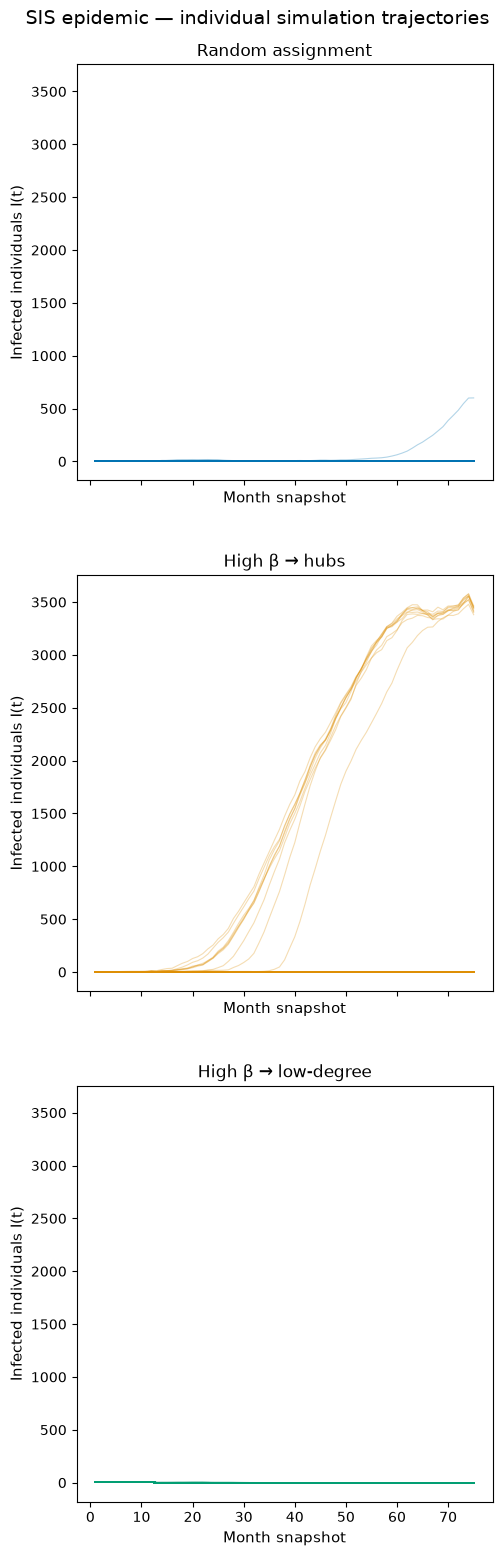

In [294]:
criteria = ['random', 'high_to_hub', 'high_to_low']
titles   = ['Random assignment', 'High β → hubs', 'High β → low-degree']
palette  = sns.color_palette('colorblind', n_colors=len(criteria))

fig, axes = plt.subplots(3, 1, figsize=(5, 16), sharex=True, sharey=True)

for ax, criterion, title, color in zip(axes, criteria, titles, palette):
    for run in sim_results[criterion]:
        ax.plot(snapshots, run, color=color, linewidth=0.8, alpha=0.3)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Month snapshot', fontsize=11)
    ax.set_ylabel('Infected individuals I(t)', fontsize=11)
    ax.set_box_aspect(1)

plt.suptitle('SIS epidemic — individual simulation trajectories', fontsize=14)
plt.tight_layout()
plt.show()

### Infected aggregated by risk category

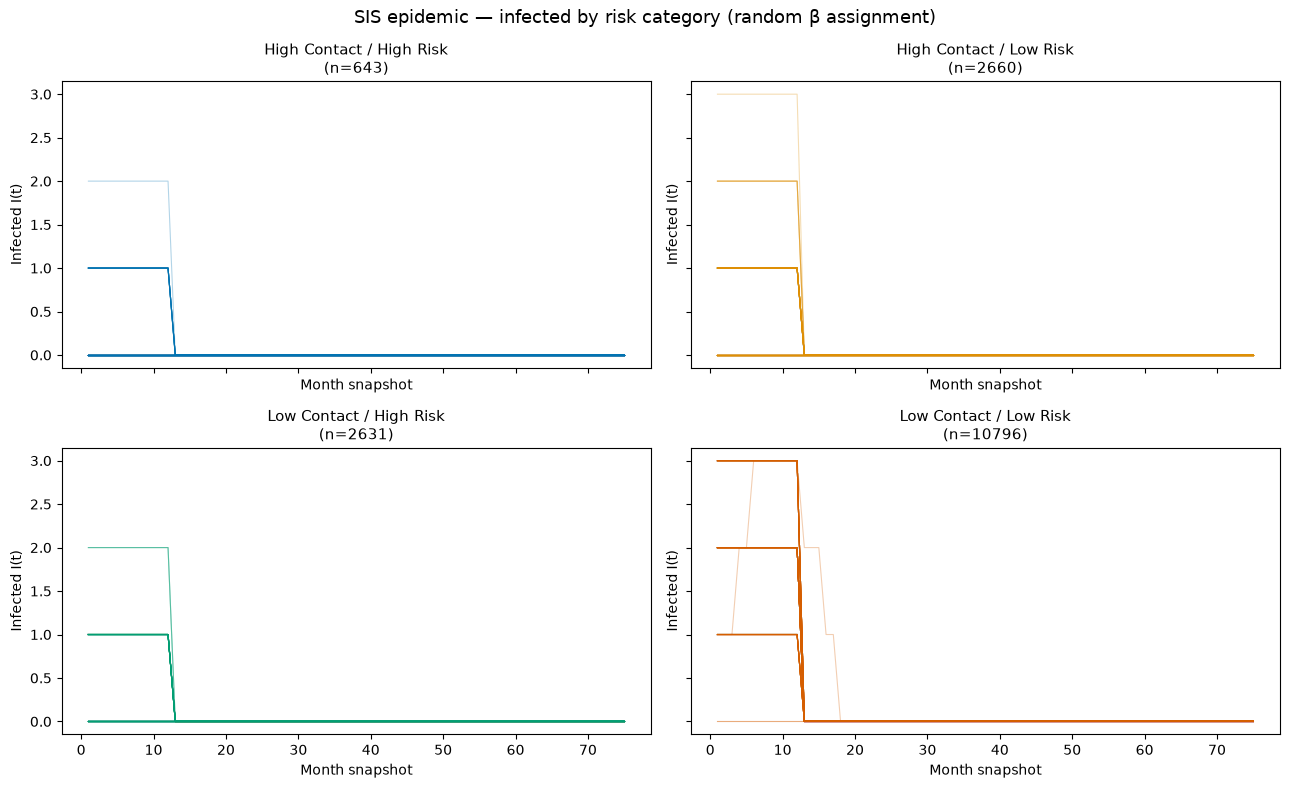

In [295]:
# Reuse beta_map_cat, node_category, cat_labels, cat_sizes, edges_by_month from the SI cell above
recovery_snapshots = round(1.0 * 12)   # default 1 year

cat_counts_SIS = {cat: np.zeros((n_sims, len(snapshots_list)), dtype=int) for cat in cat_labels}

for sim in range(n_sims):
    infection_time = {
        node: 0
        for node in np.random.choice(all_nodes, size=n_seeds, replace=False)
    }
    for t, month in enumerate(snapshots_list):
        # Recovery
        recovered = {nd for nd, t_inf in infection_time.items() if (t - t_inf) >= recovery_snapshots}
        for nd in recovered:
            del infection_time[nd]
        infected = set(infection_time.keys())
        # Transmission
        new_infected = {}
        for u, v, w in edges_by_month.get(month, []):
            if u in infected and v not in infected and v not in new_infected:
                if np.random.rand() < min(1.0, w * beta_map_cat.get(u, 0.1)):
                    new_infected[v] = t
            if v in infected and u not in infected and u not in new_infected:
                if np.random.rand() < min(1.0, w * beta_map_cat.get(v, 0.1)):
                    new_infected[u] = t
        infection_time.update(new_infected)
        for cat in cat_labels:
            cat_counts_SIS[cat][sim, t] = sum(1 for nd in infection_time if node_category[nd] == cat)

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)

for ax, cat, color in zip(axes.flatten(), cat_labels, palette4):
    for run in cat_counts_SIS[cat]:
        ax.plot(snapshots_list, run, color=color, linewidth=0.8, alpha=0.3)
    label = f'{cat[0].title()} / {cat[1].title()}\n(n={cat_sizes[cat]})'
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Month snapshot', fontsize=10)
    ax.set_ylabel('Infected I(t)', fontsize=10)

plt.suptitle('SIS epidemic — infected by risk category (random β assignment)', fontsize=13)
plt.tight_layout()
plt.show()